In [1]:
print("Hello Gautami! My research environment works.")

Hello Gautami! My research environment works.


In [2]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [3]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
import pandas as pd

In [5]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [6]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

# Convert to pandas DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [7]:
print("Dataset shape:", df.shape)

Dataset shape: (569, 31)


In [8]:
X = df.drop("target", axis=1)
y = df["target"]

print(X.head())
print(y.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (455, 30)
Testing size: (114, 30)


In [10]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [11]:
predictions = model.predict(X_test)

print(predictions[:10])

[1 0 0 1 1 0 0 0 0 1]


In [12]:
predictions = model.predict(X_test)

print(predictions[:10])

[1 0 0 1 1 0 0 0 0 1]


In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

#Calculate Accuracy

Model Accuracy: 0.9649122807017544


In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

print(cm)

#shows confusion matrix to analyze predictions

[[40  3]
 [ 1 70]]


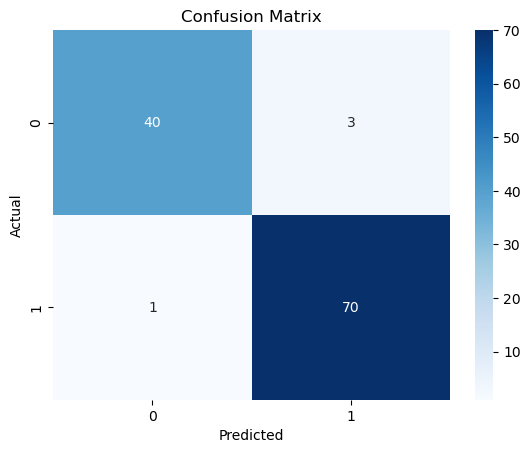

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#visulization of Confusion Matrix 
#40 correct negatives
#70 correct positives
#3 false positives
#1 false negative

In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

#calculated Accuracy, Precision, Recall, F1 score

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [17]:
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X.columns)

feature_importance.sort_values(ascending=False).head(10)

#You will see the top 10 most important features.

mean concave points     0.133810
worst concave points    0.125529
worst area              0.107244
worst perimeter         0.102181
mean area               0.084837
worst radius            0.083049
mean concavity          0.043185
mean radius             0.036908
mean perimeter          0.034453
area error              0.033914
dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

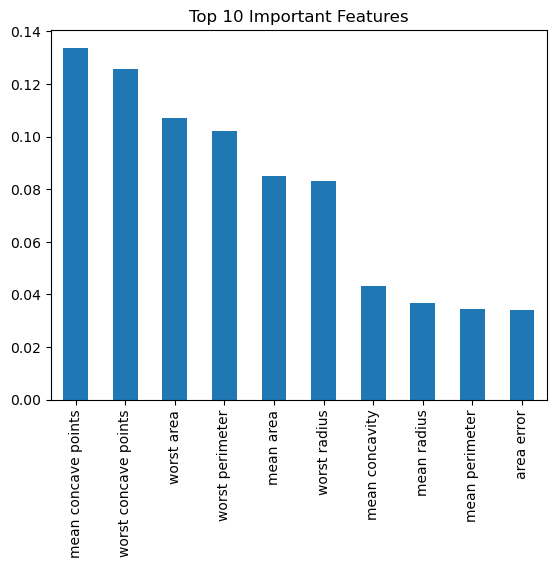

In [18]:
feature_importance.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top 10 Important Features")
plt.show

#graph of top 10 most important features.

In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

#We’ll compare: Logistic Regression (baseline),    Random Forest (strong),  SVM (also strong)

Train: (455, 30) Test: (114, 30)


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(kernel="rbf")
}

results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

results_df

#Train & evaluate 3 models
#This is my performance comparison table.

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.964912,0.959459,0.986111,0.972603
1,Random Forest,0.956140,0.958904,0.972222,0.965517
2,SVM,0.929825,0.921053,0.972222,0.945946


In [22]:
results_df_rounded = results_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    results_df_rounded[col] = results_df_rounded[col].round(3)

results_df_rounded
#clean performance comparison table - Round values (looks professional)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.965,0.959,0.986,0.973
1,Random Forest,0.956,0.959,0.972,0.966
2,SVM,0.930,0.921,0.972,0.946


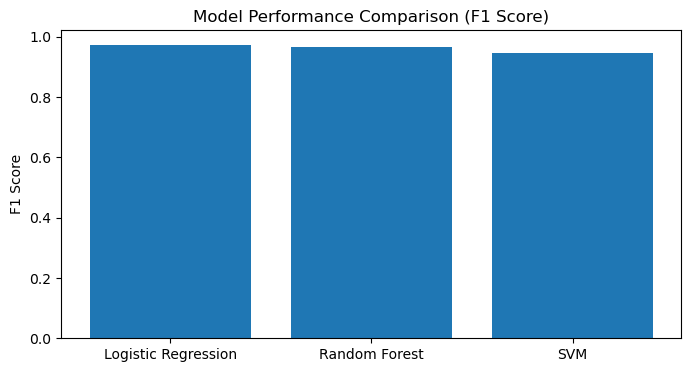

In [23]:
plt.figure(figsize=(8,4))

plt.bar(results_df["Model"], results_df["F1 Score"])

plt.title("Model Performance Comparison (F1 Score)")
plt.ylabel("F1 Score")

plt.show()

#bar chart comparing F1 scores

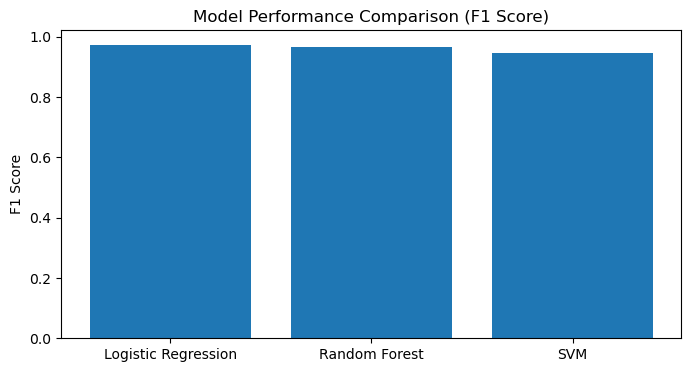

In [24]:
plt.figure(figsize=(8,4))

plt.bar(results_df["Model"], results_df["F1 Score"])

plt.title("Model Performance Comparison (F1 Score)")
plt.ylabel("F1 Score")

plt.savefig("model_comparison.png")

plt.show()

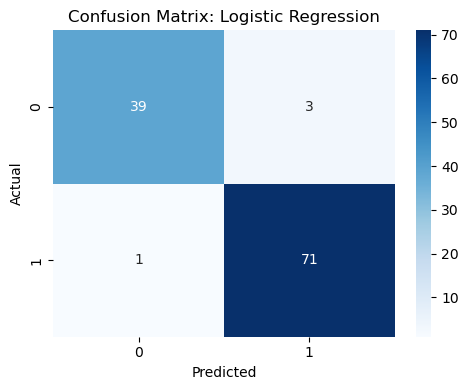

Best model: Logistic Regression


In [25]:
best_model_name = results_df.iloc[0]["Model"]
best_clf = models[best_model_name]

best_preds = best_clf.predict(X_test)
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("Best model:", best_model_name)

#confusion matrix for the best model: Logistic Regression

In [26]:
best_model = results_df.loc[results_df["F1 Score"].idxmax()]

print("Best Model:")
print(best_model)

#highlight the best model

Best Model:
Model        Logistic Regression
Accuracy                0.964912
Precision               0.959459
Recall                  0.986111
F1 Score                0.972603
Name: 0, dtype: object


In [27]:
from sklearn.model_selection import cross_val_score


# 10. Cross Validation

In [28]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(kernel="rbf")
}

cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="f1")

    cv_results.append({
        "Model": name,
        "CV F1 Mean": scores.mean(),
        "CV F1 Std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).round(3)
print(cv_results_df)


#• Random Forest performed best overall across multiple splits
#• Logistic Regression is still very strong
#• SVM is slightly weaker on this dataset

                 Model  CV F1 Mean  CV F1 Std
0  Logistic Regression       0.961      0.014
1        Random Forest       0.965      0.018
2                  SVM       0.934      0.025


# 11. XGBoost Model

In [29]:
#Install XGBoost
!pip install xgboost

In [30]:
#Import XGBoost
from xgboost import XGBClassifier

In [31]:
#Train the XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)
#the model trained.

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [32]:
# Make predictions using XGBoost
xgb_preds = xgb_model.predict(X_test)

print(xgb_preds[:10])

[0 1 0 0 0 1 1 0 0 0]


In [33]:
#Evaluate the Model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

xgb_accuracy = accuracy_score(y_test, xgb_preds)
xgb_precision = precision_score(y_test, xgb_preds)
xgb_recall = recall_score(y_test, xgb_preds)
xgb_f1 = f1_score(y_test, xgb_preds)

print("XGBoost Accuracy:", xgb_accuracy)
print("XGBoost Precision:", xgb_precision)
print("XGBoost Recall:", xgb_recall)
print("XGBoost F1 Score:", xgb_f1)

XGBoost Accuracy: 0.9473684210526315
XGBoost Precision: 0.9459459459459459
XGBoost Recall: 0.9722222222222222
XGBoost F1 Score: 0.958904109589041


In [34]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

xgb_cm = confusion_matrix(y_test, xgb_preds)

print(xgb_cm)

[[38  4]
 [ 2 70]]


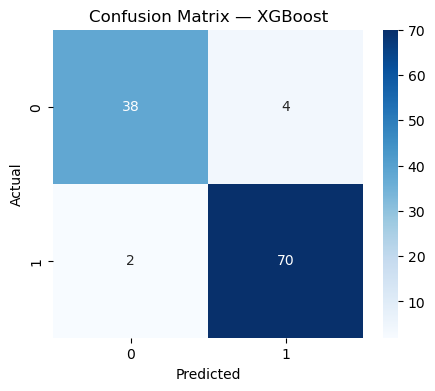

In [58]:
#Plot Confusion Matrix
plt.figure(figsize=(5,4))

sns.heatmap(xgb_cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix — XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusionmatrixXGBoost.png")   # saves image

plt.show()

# 12 Neural Network Model

In [36]:
#Import required libraries

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

In [37]:
#Neural networks work better when features are scaled.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
#Create the neural network model
nn_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=1000,
    random_state=42
)

nn_model.fit(X_train_scaled, y_train)

,hidden_layer_sizes,"(64, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


In [39]:
#Make predictions
nn_preds = nn_model.predict(X_test_scaled)

print(nn_preds[:10])

[0 1 0 0 0 1 1 0 0 0]


In [40]:
#Evaluate the model
nn_accuracy = accuracy_score(y_test, nn_preds)
nn_precision = precision_score(y_test, nn_preds)
nn_recall = recall_score(y_test, nn_preds)
nn_f1 = f1_score(y_test, nn_preds)

print("Neural Network Accuracy:", nn_accuracy)
print("Neural Network Precision:", nn_precision)
print("Neural Network Recall:", nn_recall)
print("Neural Network F1 Score:", nn_f1)

Neural Network Accuracy: 0.9649122807017544
Neural Network Precision: 0.9857142857142858
Neural Network Recall: 0.9583333333333334
Neural Network F1 Score: 0.971830985915493


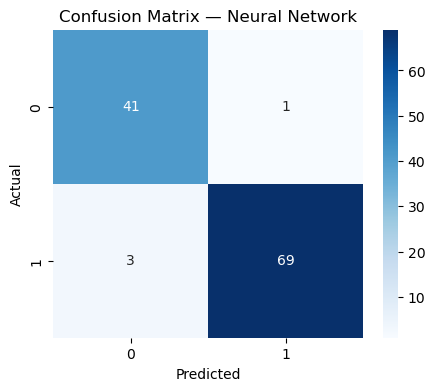

In [59]:
#Confusion Matrix
nn_cm = confusion_matrix(y_test, nn_preds)

plt.figure(figsize=(5,4))

sns.heatmap(nn_cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix — Neural Network")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusionmatrix_NeuralNetwork.png")   # saves image

plt.show()

In [42]:
from sklearn.metrics import confusion_matrix

nn_cm = confusion_matrix(y_test, nn_preds)

print(nn_cm)

[[41  1]
 [ 3 69]]


# 13 Explainable AI (SHAP)

In [43]:
#Install SHAP
!pip install shap

In [44]:
#Import SHAP
import shap

In [45]:
#SHAP works very well with tree models, so we will explain the XGBoost mode
explainer = shap.Explainer(xgb_model, X_train)
shap_values = explainer(X_test)

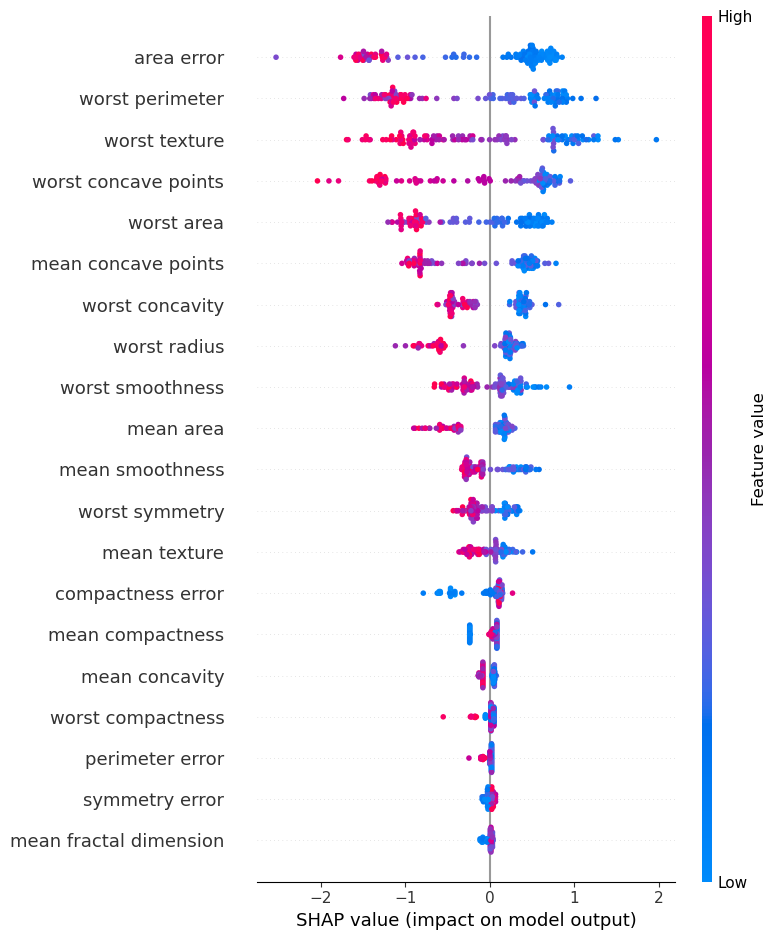

<Figure size 640x480 with 0 Axes>

In [60]:
#Global feature importance plot
shap.summary_plot(shap_values, X_test)

plt.savefig("shap_summary.png")   # saves image

#• how each feature affects predictions
#• red = high value
#• blue = low value


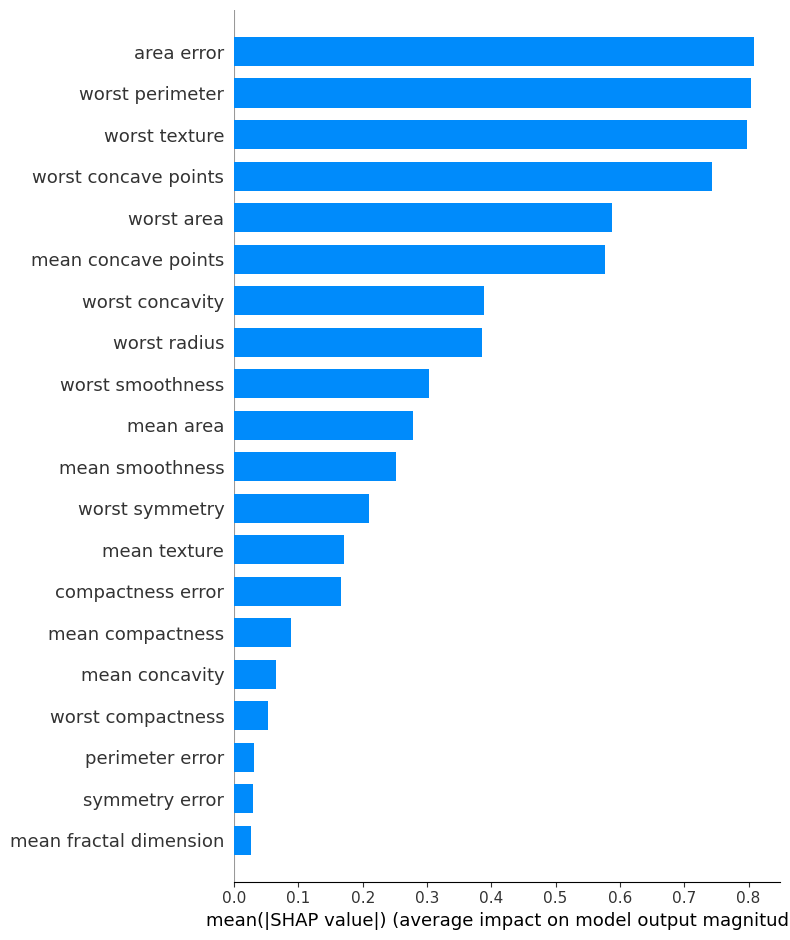

<Figure size 640x480 with 0 Axes>

In [63]:
#Bar plot of feature importance
shap.summary_plot(shap_values, X_test, plot_type="bar")

plt.savefig("shap_summary2.png")

In [48]:

# Recreate the models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Logistic Regression
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# SVM
svm_model = SVC(kernel="rbf")
svm_model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [49]:
#Create predictions
# Create predictions

log_preds = log_model.predict(X_test)
rf_preds = rf_model.predict(X_test)
svm_preds = svm_model.predict(X_test)

In [50]:
#Add Metrics Cell
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Logistic Regression metrics
log_accuracy = accuracy_score(y_test, log_preds)
log_precision = precision_score(y_test, log_preds)
log_recall = recall_score(y_test, log_preds)
log_f1 = f1_score(y_test, log_preds)

# Random Forest metrics
rf_accuracy = accuracy_score(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds)
rf_recall = recall_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)

# SVM metrics
svm_accuracy = accuracy_score(y_test, svm_preds)
svm_precision = precision_score(y_test, svm_preds)
svm_recall = recall_score(y_test, svm_preds)
svm_f1 = f1_score(y_test, svm_preds)

# 14 Final Model Comparison

In [51]:
# Create final model comparison table

final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "XGBoost",
        "Neural Network"
    ],
    "Accuracy": [
        log_accuracy,
        rf_accuracy,
        svm_accuracy,
        xgb_accuracy,
        nn_accuracy
    ],
    "Precision": [
        log_precision,
        rf_precision,
        svm_precision,
        xgb_precision,
        nn_precision
    ],
    "Recall": [
        log_recall,
        rf_recall,
        svm_recall,
        xgb_recall,
        nn_recall
    ],
    "F1 Score": [
        log_f1,
        rf_f1,
        svm_f1,
        xgb_f1,
        nn_f1
    ]
}).round(3)

final_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.965,0.959,0.986,0.973
1,Random Forest,0.956,0.959,0.972,0.966
2,SVM,0.930,0.921,0.972,0.946
3,XGBoost,0.947,0.946,0.972,0.959
4,Neural Network,0.965,0.986,0.958,0.972


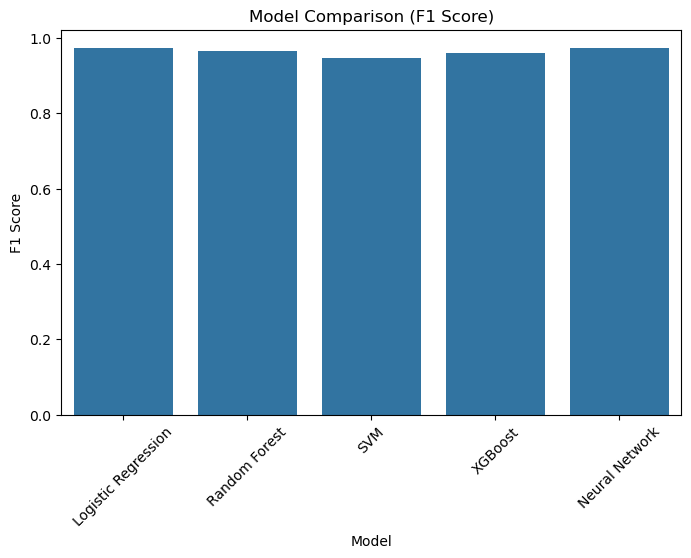

In [62]:
#Add Model Comparison Chart
plt.figure(figsize=(8,5))

sns.barplot(data=final_results, x="Model", y="F1 Score")

plt.title("Model Comparison (F1 Score)")
plt.xticks(rotation=45)

plt.savefig("model_comparison.png")

plt.show()

# 15 ROC Curve Comparison

In [53]:
#Import ROC tools
from sklearn.metrics import roc_curve, auc

In [54]:
#Get probability scores for each model
# Get probability scores for ROC curve

log_probs = log_model.predict_proba(X_test)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
nn_probs = nn_model.predict_proba(X_test_scaled)[:, 1]

# For SVM, use decision_function instead of predict_proba
svm_scores = svm_model.decision_function(X_test)

In [55]:
#Compute ROC curve and AUC
# Compute ROC curve and AUC for each model

log_fpr, log_tpr, _ = roc_curve(y_test, log_probs)
log_auc = auc(log_fpr, log_tpr)

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
rf_auc = auc(rf_fpr, rf_tpr)

svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_scores)
svm_auc = auc(svm_fpr, svm_tpr)

xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)
xgb_auc = auc(xgb_fpr, xgb_tpr)

nn_fpr, nn_tpr, _ = roc_curve(y_test, nn_probs)
nn_auc = auc(nn_fpr, nn_tpr)

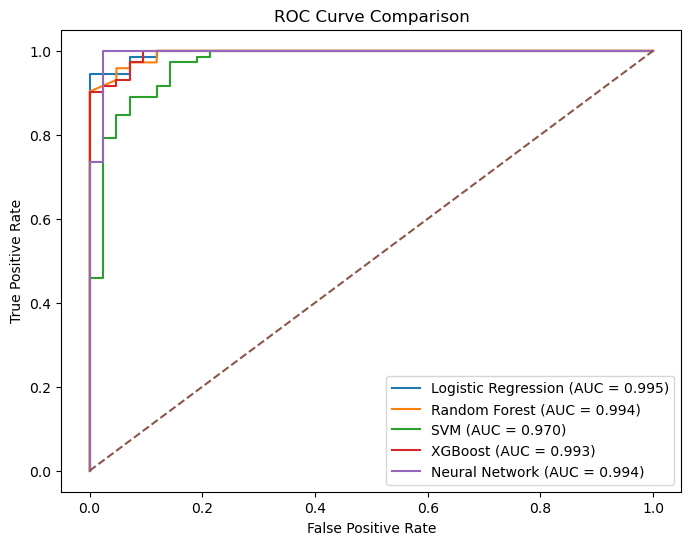

In [61]:
#Plot ROC curves
plt.figure(figsize=(8,6))

plt.plot(log_fpr, log_tpr, label=f"Logistic Regression (AUC = {log_auc:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")
plt.plot(svm_fpr, svm_tpr, label=f"SVM (AUC = {svm_auc:.3f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {xgb_auc:.3f})")
plt.plot(nn_fpr, nn_tpr, label=f"Neural Network (AUC = {nn_auc:.3f})")

# Diagonal baseline
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.savefig("roc_curve.png")   # saves image
plt.show()

In [57]:
#Create AUC comparison table
auc_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "XGBoost",
        "Neural Network"
    ],
    "AUC": [
        log_auc,
        rf_auc,
        svm_auc,
        xgb_auc,
        nn_auc
    ]
}).round(3)

auc_results

,Model,AUC
0,Logistic Regression,0.995
1,Random Forest,0.994
2,SVM,0.970
3,XGBoost,0.993
4,Neural Network,0.994


In [ ]:
#Best model by F1 and AUC

#Clinical relevance (recall emphasis)

#Top SHAP features.